In [ ]:
import json
import pandas as pd
from IPython.display import Image, display

# CIFAR-10 Image Classification: From CNN to Transfer Learning

## Project Objective
In this project I explored classification on the CIFAR-10 dataset through a number of different models, we started a simple MLP, then moved onto a baseline CNN, then improved upon that CNN with data augmentation and batch normalization, then we tested transfer learning using a pretrained Resnet18, comparing the difference between feature extraction and partial fine tuning. The goal is to understand how each ot these approaches affect test accuracy, generalization and computational costs

## Dataset and Preprocessing

### Dataset

CIFAR-10 is an image classification dataset that consists of 60,000 32x32 color images across 10 classes, that are split into training, validation, and test sets. The ten classes are: Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

## Multi Layer Perceptron (MLP)
Before the four experiments below, an early MLP baseline was trained to establish a naive reference point. Note this run was exploratory and not part of the experimentation.

**Architecture:**
MLP( <br> 
(fc1): Linear(in_features=3072, out_features=512, bias=True) <br>
(fc2): Linear(in_features=512, out_features=256, bias=True) <br>
(fc3): Linear(in_features=256, out_features=10, bias=True) <br>
(relu): ReLU() <br>
) <br>

**Result:** Test Accuracy: 49.57%

**Observations:** The model learned slowly, made many near random mistakes, and struggled particularly with animal classes (e.g., cat vs. dog). This result established the baseline that every subsequent architecture change was measured against.

## Experiment 1: CNN Baseline

**Configuration:**

Model: CNN <br>
Data Augmentation: False <br>
Batch Size: 64 <br>
Optimizer: Adam <br>
Learning Rate: 0.001 <br>
Weight Decay: 0.0 <br>
Epochs: 10 <br>
Seed: 42 <br>


**Architecture:**

CNN( <br>
(conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) <br> 
(relu): ReLU() <br>
(pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False) <br>
(conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) <br>
(flatten): Flatten(start_dim=1, end_dim=-1) <br>
(fc1): Linear(in_features=4096, out_features=512, bias=True) <br>
(fc2): Linear(in_features=512, out_features=10, bias=True) <br>
) <br>

In [ ]:
with open("results/cnn_baseline.json") as f:
    cnn_baseline = json.load(f)

print(f"Validation Accuracy: {cnn_baseline['validation_accuracy']}%")
print(f"Test Accuracy: {cnn_baseline['test_accuracy']*100:.2f}%")
print(f"Precision: {cnn_baseline['precision']:.4f}")
print(f"Recall: {cnn_baseline['recall']:.4f}")
print(f"F1 Score: {cnn_baseline['f1']:.4f}")

Validation Accuracy: 73.02%
Test Accuracy: 72.06%
Precision: 0.7365
Recall: 0.7206
F1 Score: 0.7240


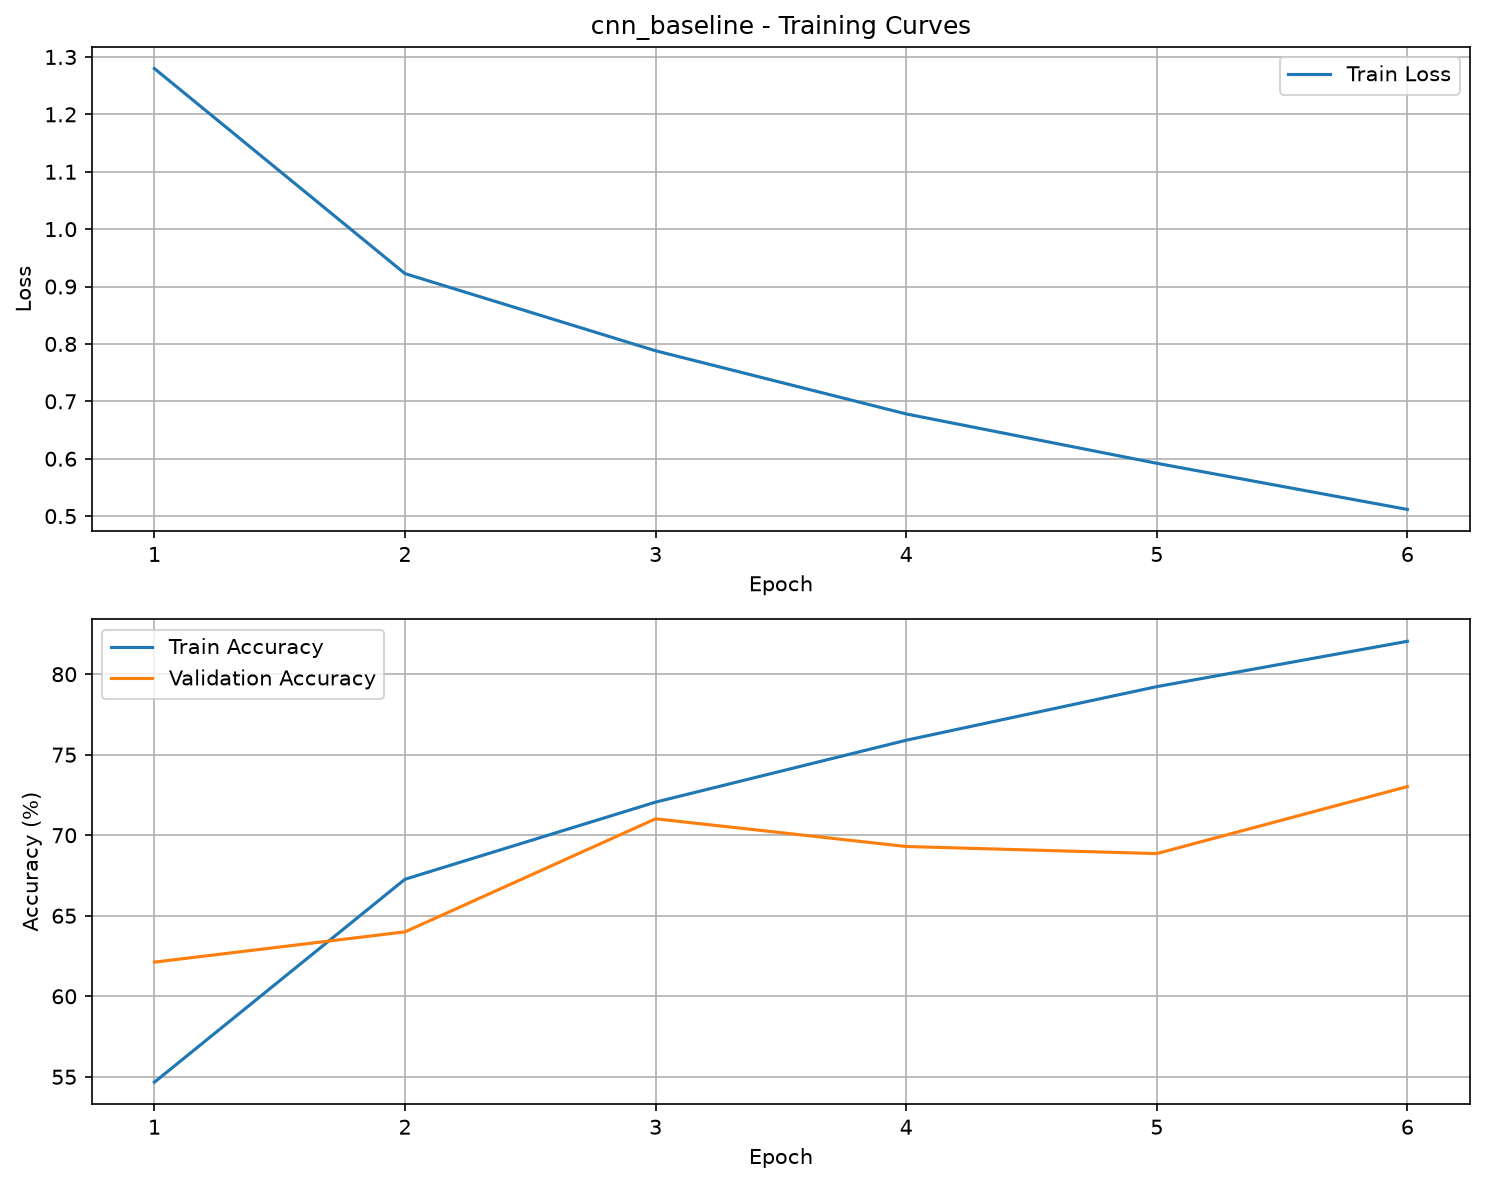

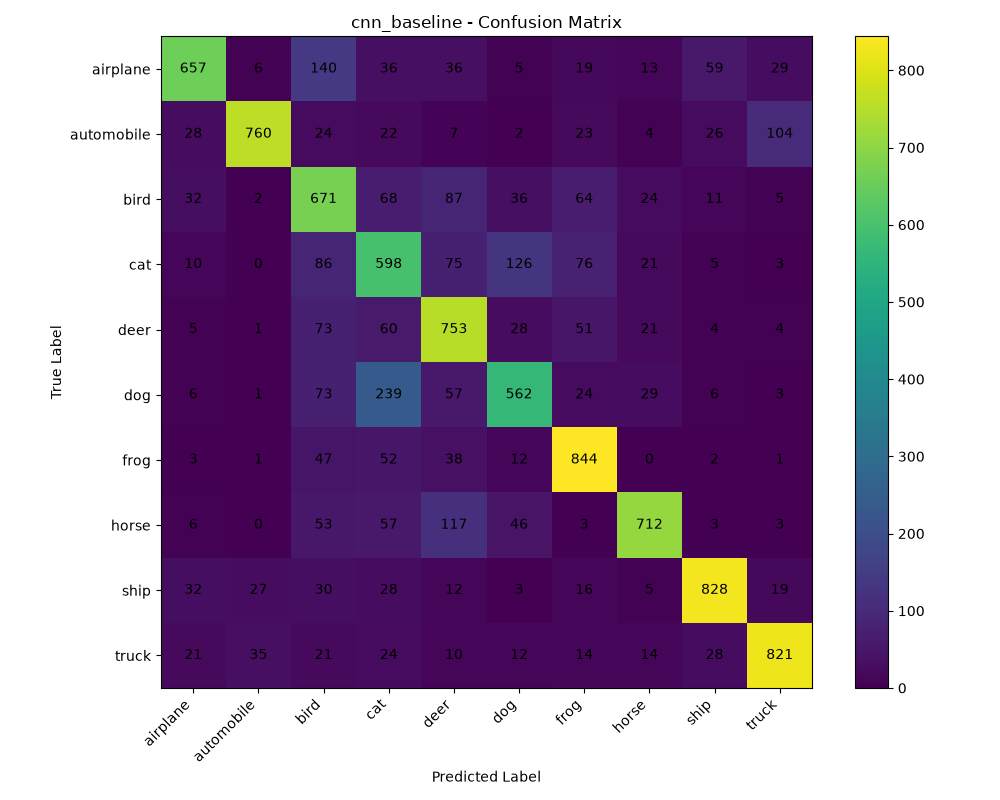

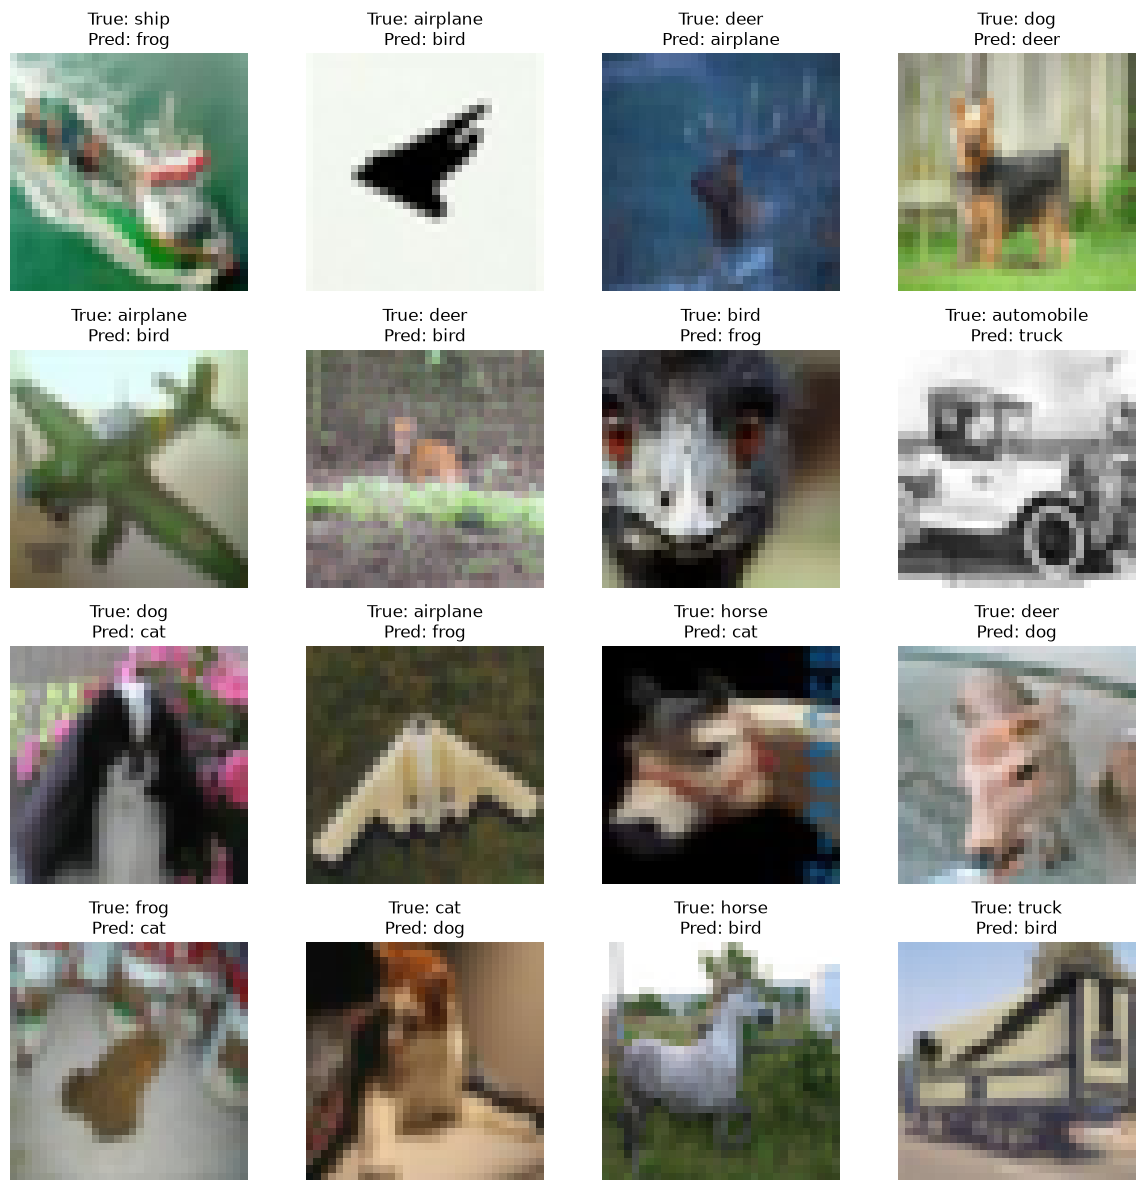

In [ ]:
display(Image("results/cnn_baseline_training_curves.png"))
display(Image("results/cnn_baseline_confusion_matrix.png"))
display(Image("results/cnn_baseline_misclassified.png"))

This simple two-layer CNN reached **72.06% test accuracy**, a substantial jump over the MLP baseline, confirming the value of convolutional structure for image data. Training took 19.75 minutes.

## Experiment 2: CNN Best (Augmentation + BatchNorm)

**Configuration:** <br>
Model: CNN <br>
Data Augmentation: True <br>
Batch Normalization: True <br>
Batch Size: 32 <br>
Optimizer: Adam <br>
Learning Rate: 0.001 <br>
Weight Decay: 0.0 <br>
Epochs: 20 <br>
Seed: 42 <br>

**Changes from baseline:** Added data augmentation (random flips/crops) and batch normalization, reduced batch size to 32, and trained for 20 epochs instead of 10.

In [ ]:
with open("results/cnn_best.json") as f:
    cnn_best = json.load(f)

print(f"Validation Accuracy: {cnn_best['validation_accuracy']}%")
print(f"Test Accuracy: {cnn_best['test_accuracy']*100:.2f}%")
print(f"Precision: {cnn_best['precision']:.4f}")
print(f"Recall: {cnn_best['recall']:.4f}")
print(f"F1 Score: {cnn_best['f1']:.4f}")

Validation Accuracy: 76.98%
Test Accuracy: 76.70%
Precision: 0.7759
Recall: 0.7670
F1 Score: 0.7685


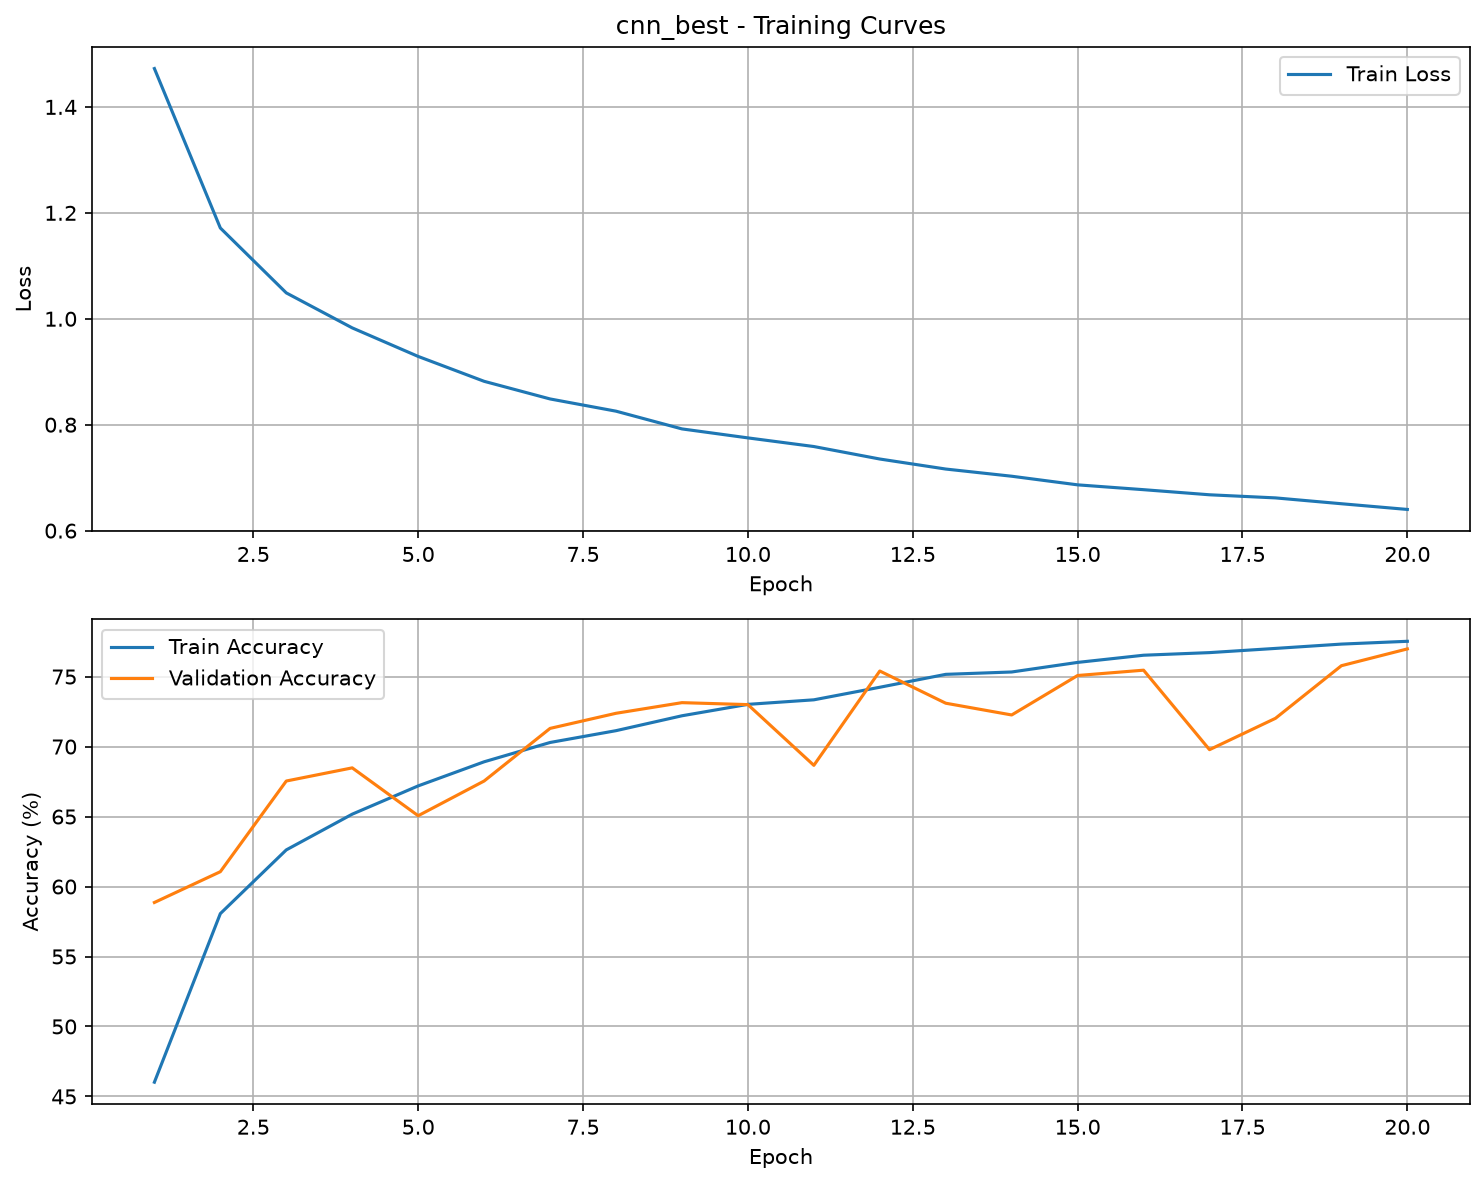

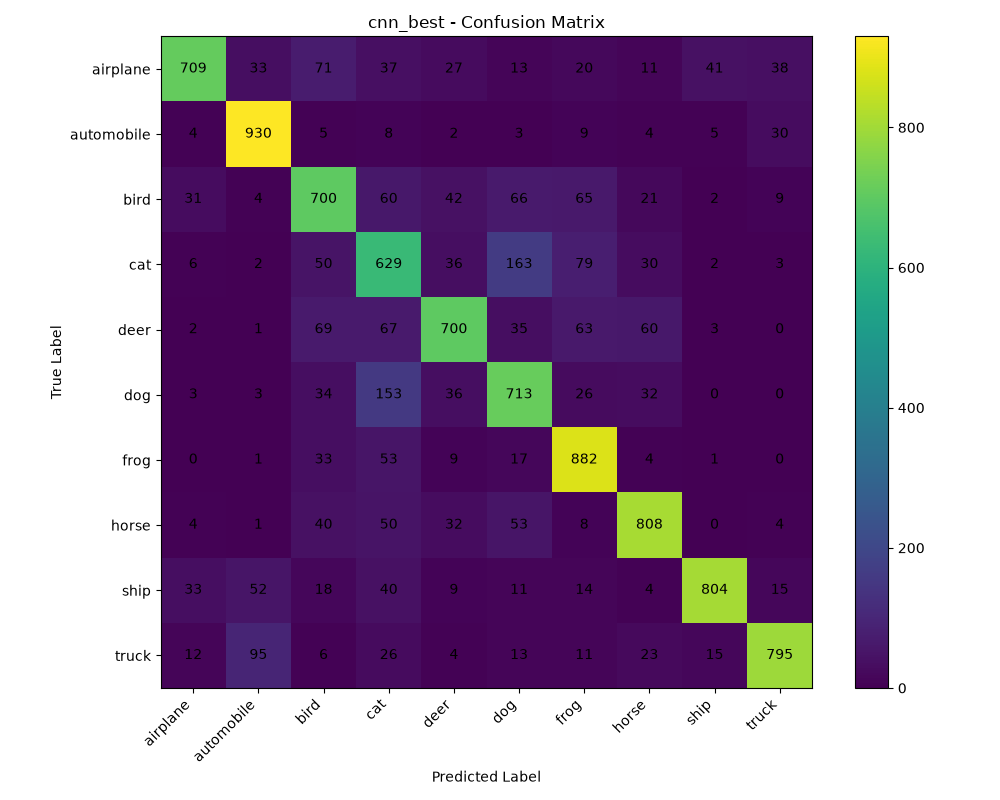

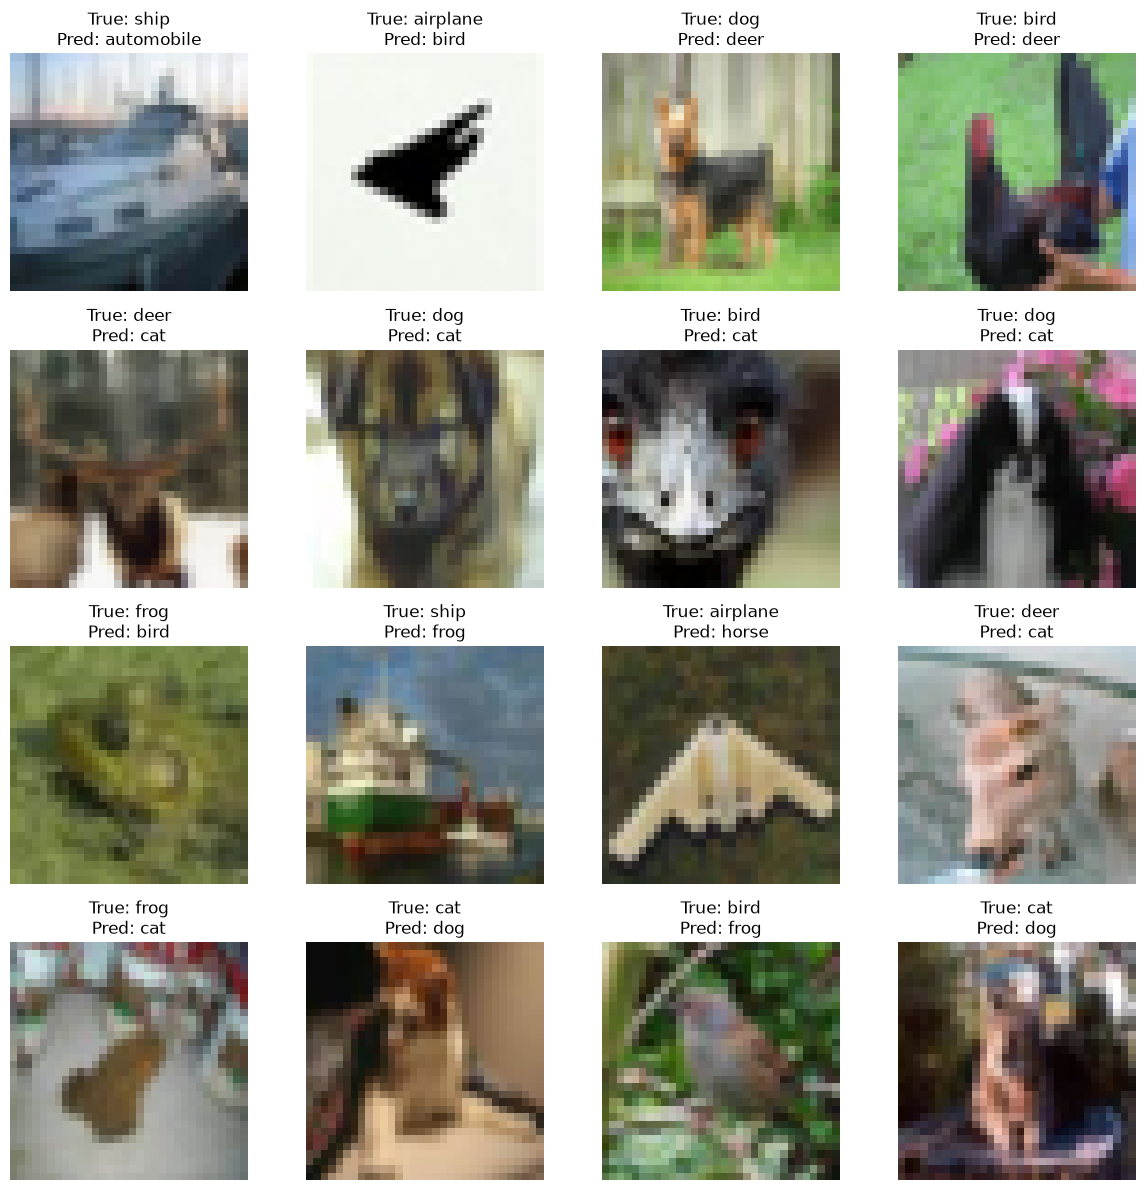

In [ ]:
display(Image("results/cnn_best_training_curves.png"))
display(Image("results/cnn_best_confusion_matrix.png"))
display(Image("results/cnn_best_misclassified.png"))

Augmentation and batch normalization pushed test accuracy to **76.70%**, a +4.64 point improvement over the CNN baseline, at the cost of roughly 2.7x more training time (52.62 minutes).

## Experiment 3: ResNet18 — Feature Extraction

**Approach:** Load a pretrained ResNet18 , freeze the entire convolutional backbone, and train only a new classifier head on CIFAR-10.

**Configuration:** <br>
Model: Pretrained ResNet18 <br>
Training Strategy: Feature Extraction <br>
Backbone: Frozen <br>
Classifier: Trainable <br>
Data Augmentation: True <br>
Batch Size: 64 <br>
Optimizer: Adam <br>
Learning Rate: 0.001 <br>
Epochs: 10 <br>
Seed: 42

In [ ]:
with open("results/resnet_feature.json") as f:
    resnet_feature = json.load(f)

print(f"Validation Accuracy: {resnet_feature['validation_accuracy']}%")
print(f"Test Accuracy: {resnet_feature['test_accuracy']*100:.2f}%")
print(f"Precision: {resnet_feature['precision']:.4f}")
print(f"Recall: {resnet_feature['recall']:.4f}")
print(f"F1 Score: {resnet_feature['f1']:.4f}")

Validation Accuracy: 81.0%
Test Accuracy: 80.65%
Precision: 0.8098
Recall: 0.8065
F1 Score: 0.8071


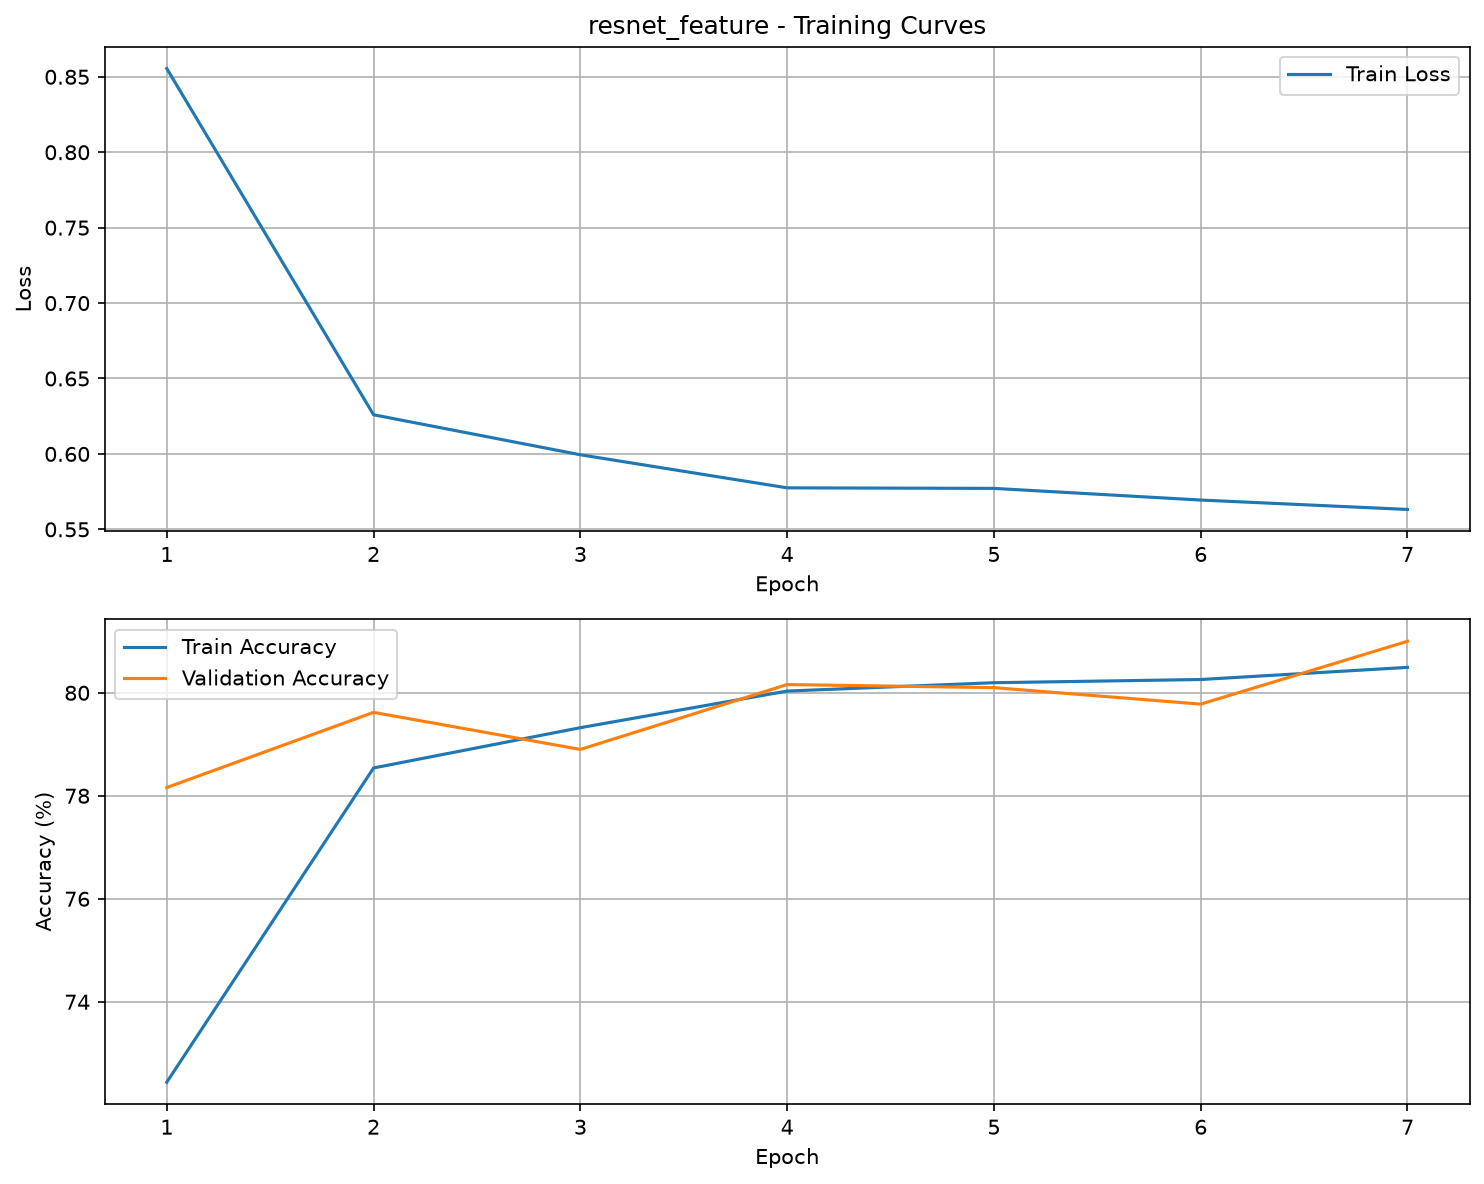

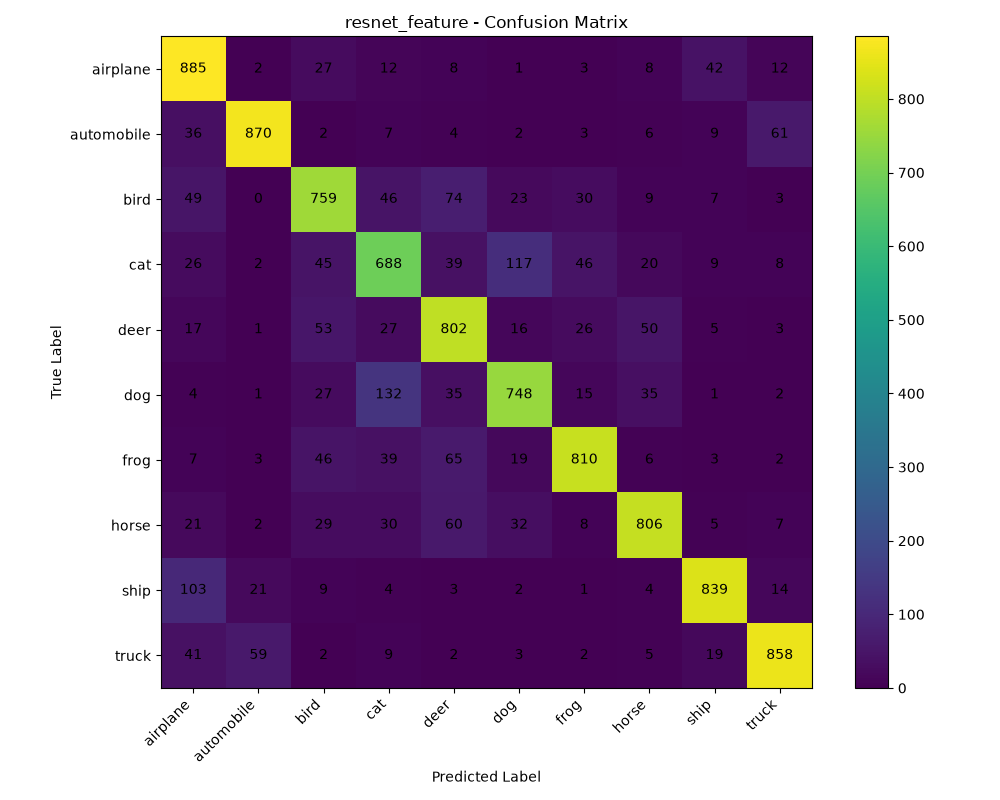

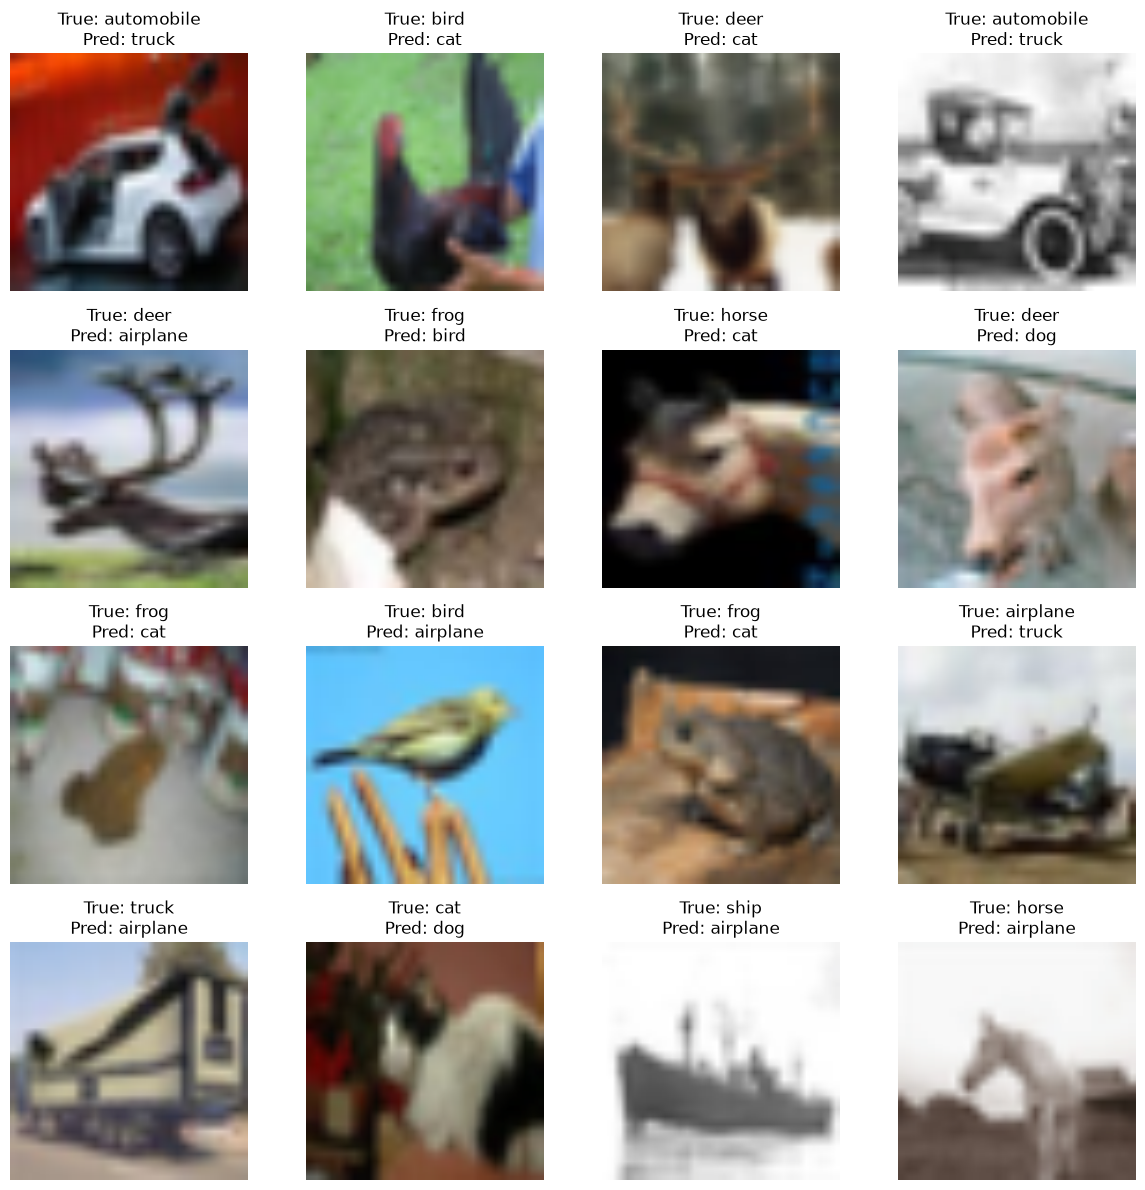

In [ ]:
display(Image("results/resnet_feature_training_curves.png"))
display(Image("results/resnet_feature_confusion_matrix.png"))
display(Image("results/resnet_feature_misclassified.png"))

Using frozen ImageNet pretrained features gave **80.65% test accuracy** better than either CNN, despite the backbone not seeing CIFAR-10 during training. This shows that general visual features learned on ImageNet transfer reasonably well to CIFAR-10, even without adaptation. Training time increased sharply to 7.68 hours (CPU).

## Experiment 4: ResNet18 — Fine-Tuning

**Approach:** Same pretrained ResNet18, but freeze only the early layers (layers 1-3) and allow the final residual block (layer4) plus the classifier to update during training, letting the network adapt higher level features to CIFAR-10 specifically.

**Configuration:** <br>
Model: Pretrained ResNet18 <br>
Training Strategy: Partial Fine-Tuning <br>
Frozen: Layers 1-3 <br>
Trainable: Layer 4 + Classifier <br>
Data Augmentation: True <br>
Batch Size: 64 <br>
Optimizer: Adam <br>
Learning Rate: 0.001 <br>
Epochs: 10 <br>
Seed: 42

In [ ]:
with open("results/resnet_finetune.json") as f:
    resnet_finetune = json.load(f)

print(f"Validation Accuracy: {resnet_finetune['validation_accuracy']}%")
print(f"Test Accuracy: {resnet_finetune['test_accuracy']*100:.2f}%")
print(f"Precision: {resnet_finetune['precision']:.4f}")
print(f"Recall: {resnet_finetune['recall']:.4f}")
print(f"F1 Score: {resnet_finetune['f1']:.4f}")

Validation Accuracy: 91.56%
Test Accuracy: 90.72%
Precision: 0.9089
Recall: 0.9072
F1 Score: 0.9074


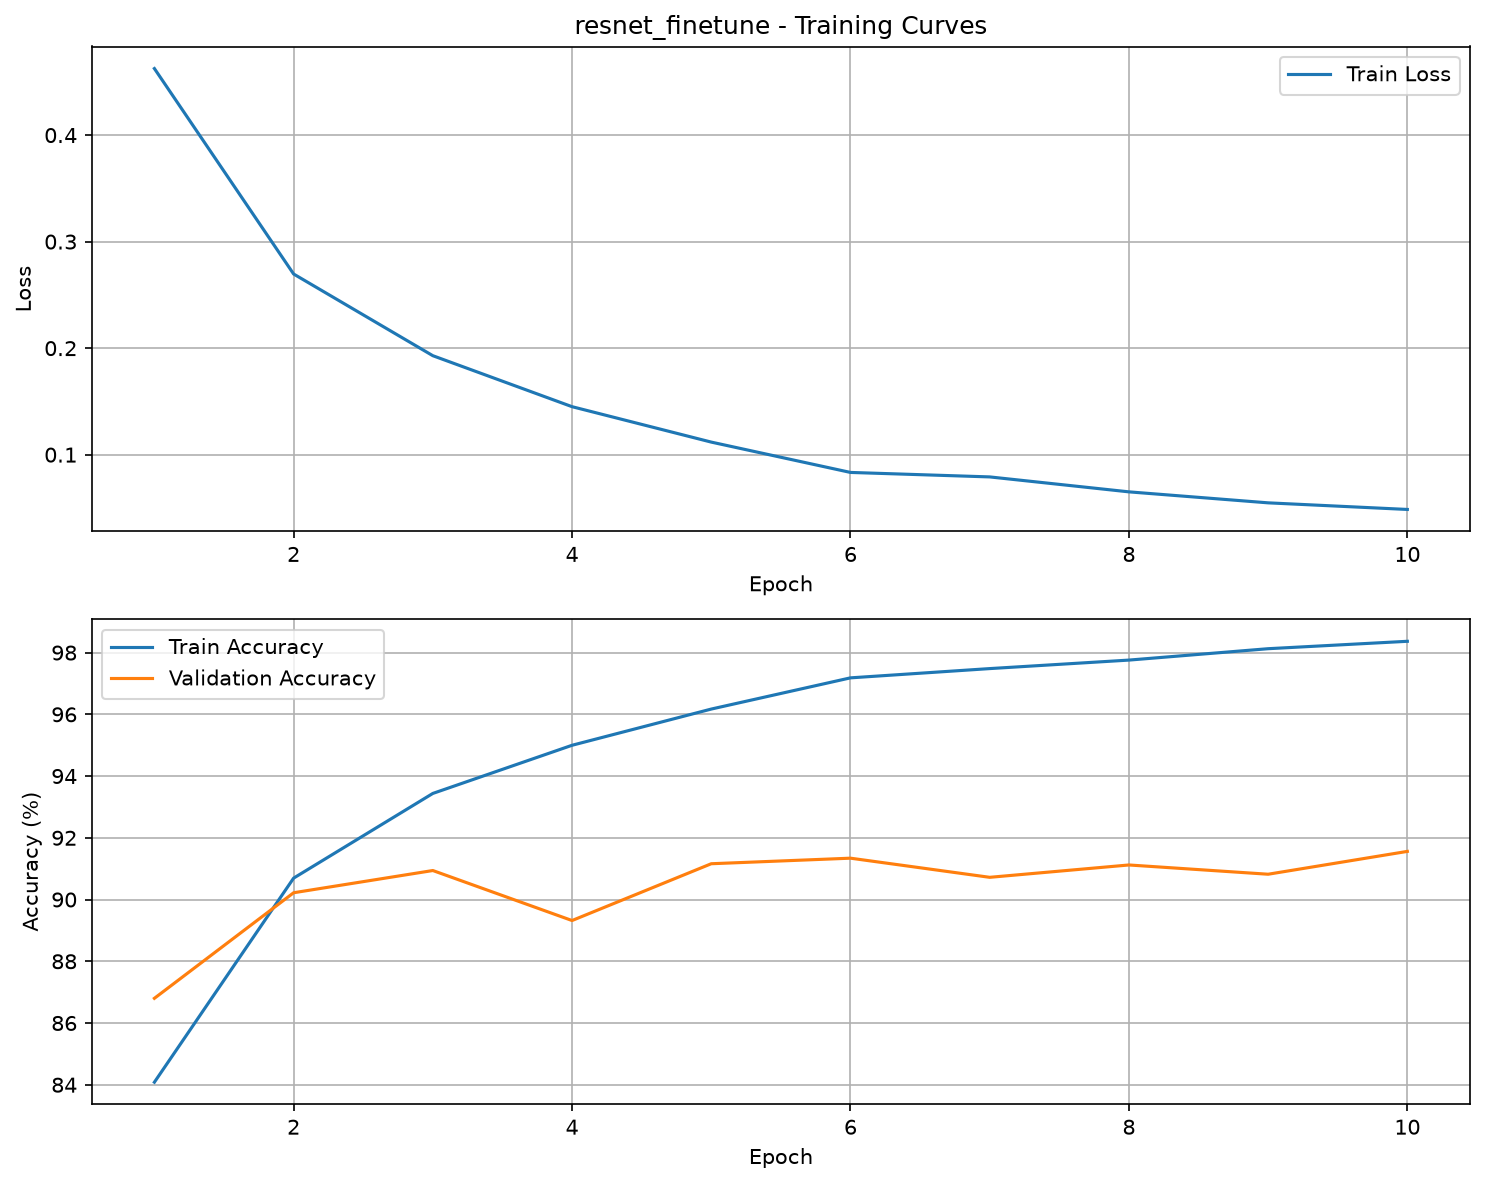

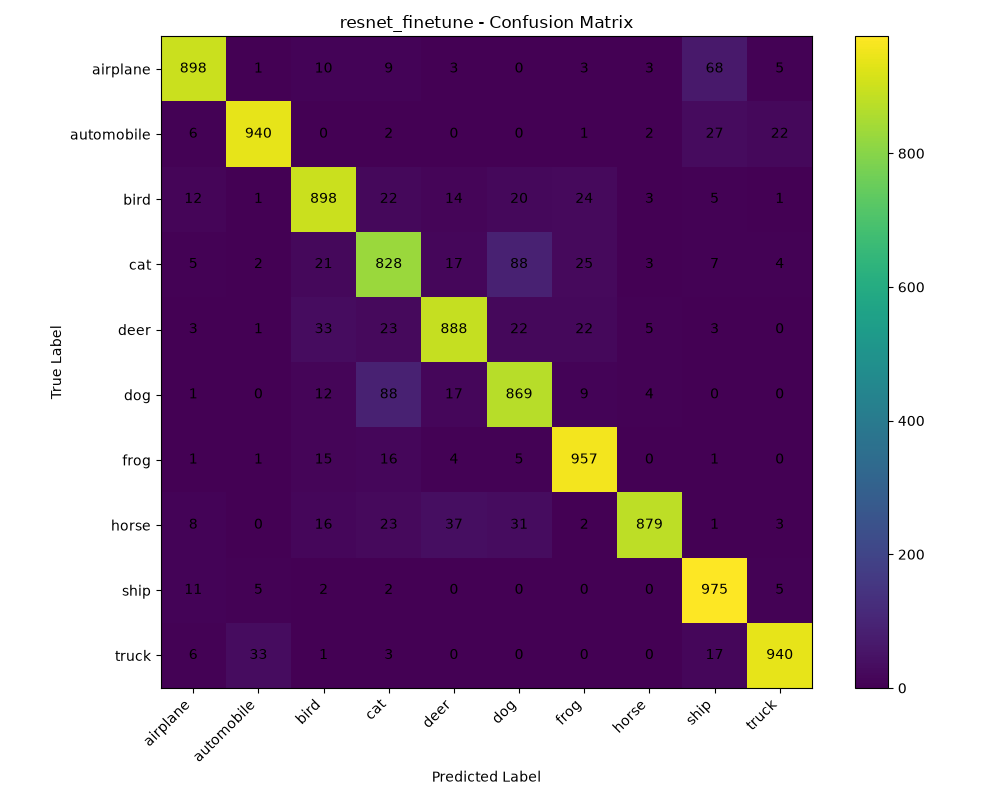

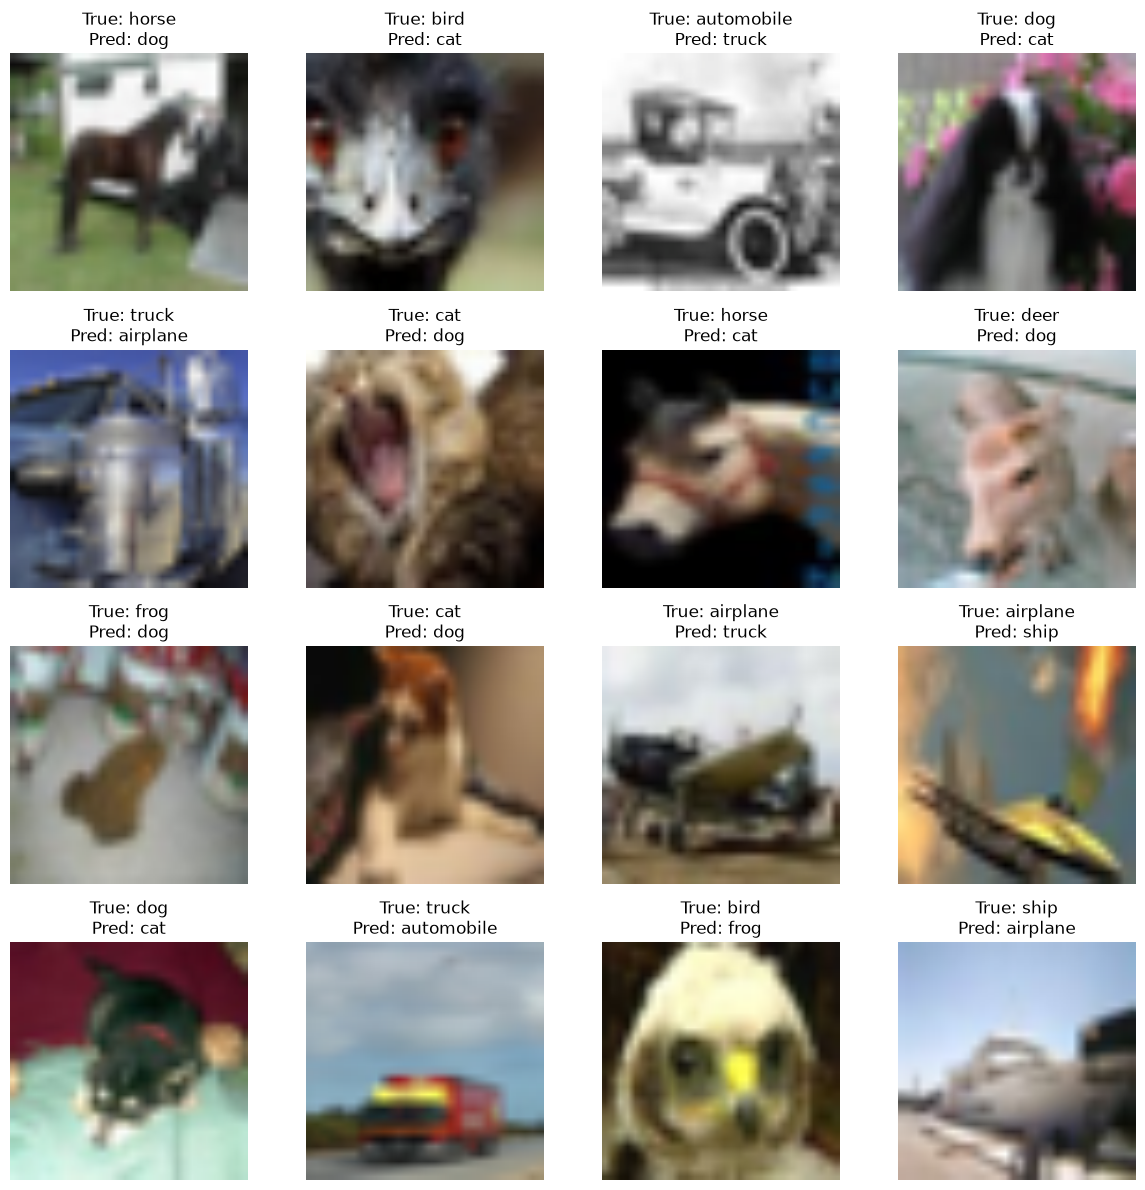

In [ ]:
display(Image("results/resnet_finetune_training_curves.png"))
display(Image("results/resnet_finetune_confusion_matrix.png"))
display(Image("results/resnet_finetune_misclassified.png"))

Fine-tuning the final residual block produced the strongest result by a wide margin: **90.72% test accuracy**, a +10.07 point jump over feature
extraction alone. This confirms that letting later layers adapt to CIFAR-10-specific features matters far more than simply having a pretrained backbone. Training time rose further to 9.37 hours.

## Master Comparison

In [ ]:
comparison = pd.DataFrame([
    {"Model": "MLP Baseline ", "Test Accuracy": "49.57%", "F1": "-", "Training Time": "-"},
    {"Model": "CNN Baseline", "Test Accuracy": "72.06%", "F1": "0.7240", "Training Time": "19.75 min"},
    {"Model": "CNN Best", "Test Accuracy": "76.70%", "F1": "0.7685", "Training Time": "52.62 min"},
    {"Model": "ResNet18 Feature Extraction", "Test Accuracy": "80.65%", "F1": "0.8071", "Training Time": "7.68 h"},
    {"Model": "ResNet18 Fine-Tuning", "Test Accuracy": "90.72%", "F1": "0.9074", "Training Time": "9.37 h"},
])
comparison

,Model,Test Accuracy,F1,Training Time
0,MLP Baseline,49.57%,-,-
1,CNN Baseline,72.06%,0.7240,19.75 min
2,CNN Best,76.70%,0.7685,52.62 min
3,ResNet18 Feature Extraction,80.65%,0.8071,7.68 h
4,ResNet18 Fine-Tuning,90.72%,0.9074,9.37 h


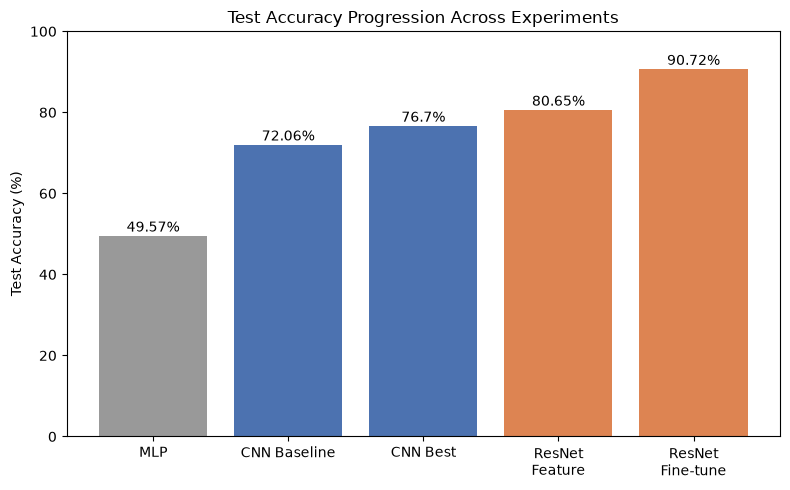

In [ ]:
import matplotlib.pyplot as plt

models = ["MLP", "CNN Baseline", "CNN Best", "ResNet\nFeature", "ResNet\nFine-tune"]
accuracies = [49.57, 72.06, 76.70, 80.65, 90.72]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=["#999", "#4C72B0", "#4C72B0", "#DD8452", "#DD8452"])
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy Progression Across Experiments")
plt.ylim(0, 100)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 1, f"{acc}%", ha="center")
plt.tight_layout()
plt.savefig("results/accuracy_comparison.png", dpi=150)
plt.show()

## Analysis

**Which model performed best?** The fine-tuned ResNet18 performed the best at 90.72% test accuracy, outperforming every other configuration
by a big margin.

**How much did each step help?** Moving from a plain CNN to one with augmentation and batch normalization added +4.64 points (72.06% to 76.70%). Switching to a pretrained ResNet18 backbone (feature extraction) added a further +3.95 points (76.70% to 80.65%). Allowing the final block to fine-tune added the largest jump, +10.07 points (80.65% to 90.72%). Overall, the CNN baseline to fine-tuned ResNet18 progression represents a +18.66 point improvement in test accuracy.

**Why did transfer learning help?** ResNet18's ImageNet-pretrained weights encode general lower and mid-level visual features like edges, textures, shapes that are broadly useful across natural images, including CIFAR-10, even without any CIFAR-10-specific adaptation.

**Why did fine-tuning produce such a large jump?** While early convolutional layers learn generic features that transfer same as they were, later layers encode increasingly task specific representations tuned to ImageNet's 1000 classes. Unfreezing the final residual block let the network re-encode those higher-level features for CIFAR-10's 10 classes and lower image resolution, which a frozen backbone cannot do.

**What happened to generalization?** The fine-tuned model reached 98.37% training accuracy but only 90.72% test accuracy, which was a noticeably larger train/test gap than any earlier model. This suggests the additional trainable parameters allowed the model to fit the training set more tightly, and while test performance still improved overall, the generalization gap itself grew.

**What was the computational cost?** Accuracy gains came with rising training time: from 20 minutes (CNN baseline) to over 9 hours (fine-tuned
ResNet18), roughly a 28x increase in training time for an 18.66 point accuracy gain. This is an important practical tradeoff, not just a "bigger is
better" story.

## Conclusion

This project demonstrates a clear progression in CIFAR-10 classification performance: from a naive MLP (49.57%), to a basic CNN (72.06%), to an improved CNN with augmentation and batch normalization (76.70%), to transfer learning via a pretrained ResNet18, first with a frozen backbone (80.65%), then with partial fine tuning (90.72%). The results show that pretrained features transfer well to CIFAR-10 even without adaptation, but that allowing later layers to fine-tune provides the largest single improvement, at a significant computational cost and a wider generalization gap that would be worth investigating further.

In [ ]:
# Run this after Restart & Run All to confirm nothing broke
print("All sections loaded successfully.")

All sections loaded successfully.
